# 🌍 Global Electricity Access & Economic Indicators (2000–2024)
### World Bank Data | 200+ Countries | 9 Indicators | SDG-7 Analysis

**Dataset:** `electricity_access.csv`  
**Source:** World Bank Open Data  
**Author:** Muhammad Aammar Tufail

---

### 📋 Columns at a Glance

| Column | Description | Unit |
|--------|-------------|------|
| `country` | Country / Region | — |
| `date` | Year | Year |
| `GDP_Per_Capita_Current_USD` | GDP per capita | USD |
| `Total_Population` | Total population | Count |
| `Population_Female_Percentage` | Female share | % |
| `Population_Male_Percentage` | Male share | % |
| `Electricity_Access_Urban_Percentage` | Urban electricity access | % |
| `Electricity_Access_Rural_Percentage` | Rural electricity access | % |
| `Total_Electricity_Output_GWh` | Net electricity generation | GWh |

---

### ❓ Questions Answered in This Notebook

**🟢 Beginner**
1. Which countries had 100% electricity access (urban + rural) by 2015?
2. What is the global average rural electricity access trend (2000–2016)?
3. Top 10 countries by GDP per capita in 2023?
4. How has global population changed (2000–2024)?

**🟡 Intermediate**
5. Is there a correlation between GDP per capita and electricity access?
6. Which regions show fastest rural electricity access growth?
7. How does electricity output relate to population?
8. Which countries have the largest urban–rural electricity gap?

**🔴 Advanced**
9. Forecast electricity access rates to 2030 (SDG-7)
10. Cluster countries by electrification & economic profile
11. Which countries are off-track for SDG-7 universal access?

## 1. 📦 Installing & Importing Required Libraries

In [1]:
# Install any missing packages (uncomment if needed)
# !pip install plotly statsmodels scikit-learn seaborn -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy import stats
import statsmodels.api as sm

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


## 2. 📂 Loading & Inspecting the Dataset

In [2]:
df = pd.read_csv("/kaggle/input/global-electricity-access-and-economic-indicators/global_electricity_access_economic_indicators.csv")

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Shape: (7381, 9)

Column dtypes:
country                                 object
date                                     int64
GDP_Per_Capita_Current_USD             float64
Total_Population                       float64
Population_Female_Percentage           float64
Population_Male_Percentage             float64
Electricity_Access_Urban_Percentage    float64
Electricity_Access_Rural_Percentage    float64
Total_Electricity_Output_GWh           float64
dtype: object

First 5 rows:


,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
0,Afghanistan,2000,174.930991,20130327.0,49.853544,50.146456,69.640984,NaN,687.7
1,Afghanistan,2001,138.706822,20284307.0,49.814443,50.185557,71.371780,NaN,691.1
2,Afghanistan,2002,178.954088,21378117.0,49.774819,50.225181,73.099968,NaN,722.2
3,Afghanistan,2003,198.871116,22733049.0,49.735361,50.264639,74.828354,NaN,976.0
4,Afghanistan,2004,221.763654,23560654.0,49.697774,50.302226,76.559761,NaN,780.0


In [3]:
print("Last 5 rows:")
display(df.tail())
print("\nBasic Statistics:")
df.describe()

Last 5 rows:


,country,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
7376,Zimbabwe,2020,2059.674454,15526888.0,52.530169,47.469831,NaN,NaN,NaN
7377,Zimbabwe,2021,2613.605421,15797210.0,52.488560,47.511440,NaN,NaN,NaN
7378,Zimbabwe,2022,2536.400502,16069056.0,52.438295,47.561705,NaN,NaN,NaN
7379,Zimbabwe,2023,2195.224921,16340822.0,52.383460,47.616540,NaN,NaN,NaN
7380,Zimbabwe,2024,2497.203322,16634373.0,52.333109,47.666891,NaN,NaN,NaN



Basic Statistics:


,date,GDP_Per_Capita_Current_USD,Total_Population,Population_Female_Percentage,Population_Male_Percentage,Electricity_Access_Urban_Percentage,Electricity_Access_Rural_Percentage,Total_Electricity_Output_GWh
count,7381.000000,6433.000000,6.625000e+03,6625.000000,6625.000000,3675.000000,3376.000000,3.647000e+03
mean,2011.603848,14909.428920,2.886783e+08,50.046758,49.953242,88.756413,72.852278,8.696355e+04
std,7.117687,23577.553825,9.013583e+08,2.611407,2.611407,20.502681,35.999818,3.957378e+05
min,2000.000000,109.593814,9.544000e+03,23.817993,45.048132,0.000000,0.007659,0.000000e+00
25%,2005.000000,1563.105911,1.463495e+06,49.570081,48.944370,87.972973,42.387517,3.955000e+02
50%,2011.000000,5126.053316,9.745953e+06,50.304102,49.695898,99.547373,95.904735,4.980000e+03
75%,2018.000000,18780.127512,6.000225e+07,51.055630,50.429919,100.000000,100.000000,3.639900e+04
max,2024.000000,288001.433369,8.141809e+09,54.951868,76.182007,100.000000,100.000000,5.844158e+06


## 3. 🧹 Data Cleaning & Handling Missing Values

                                     Missing Count  Missing %
Electricity_Access_Rural_Percentage           4005      54.26
Total_Electricity_Output_GWh                  3734      50.59
Electricity_Access_Urban_Percentage           3706      50.21
GDP_Per_Capita_Current_USD                     948      12.84
Total_Population                               756      10.24
Population_Male_Percentage                     756      10.24
Population_Female_Percentage                   756      10.24
country                                          0       0.00
date                                             0       0.00


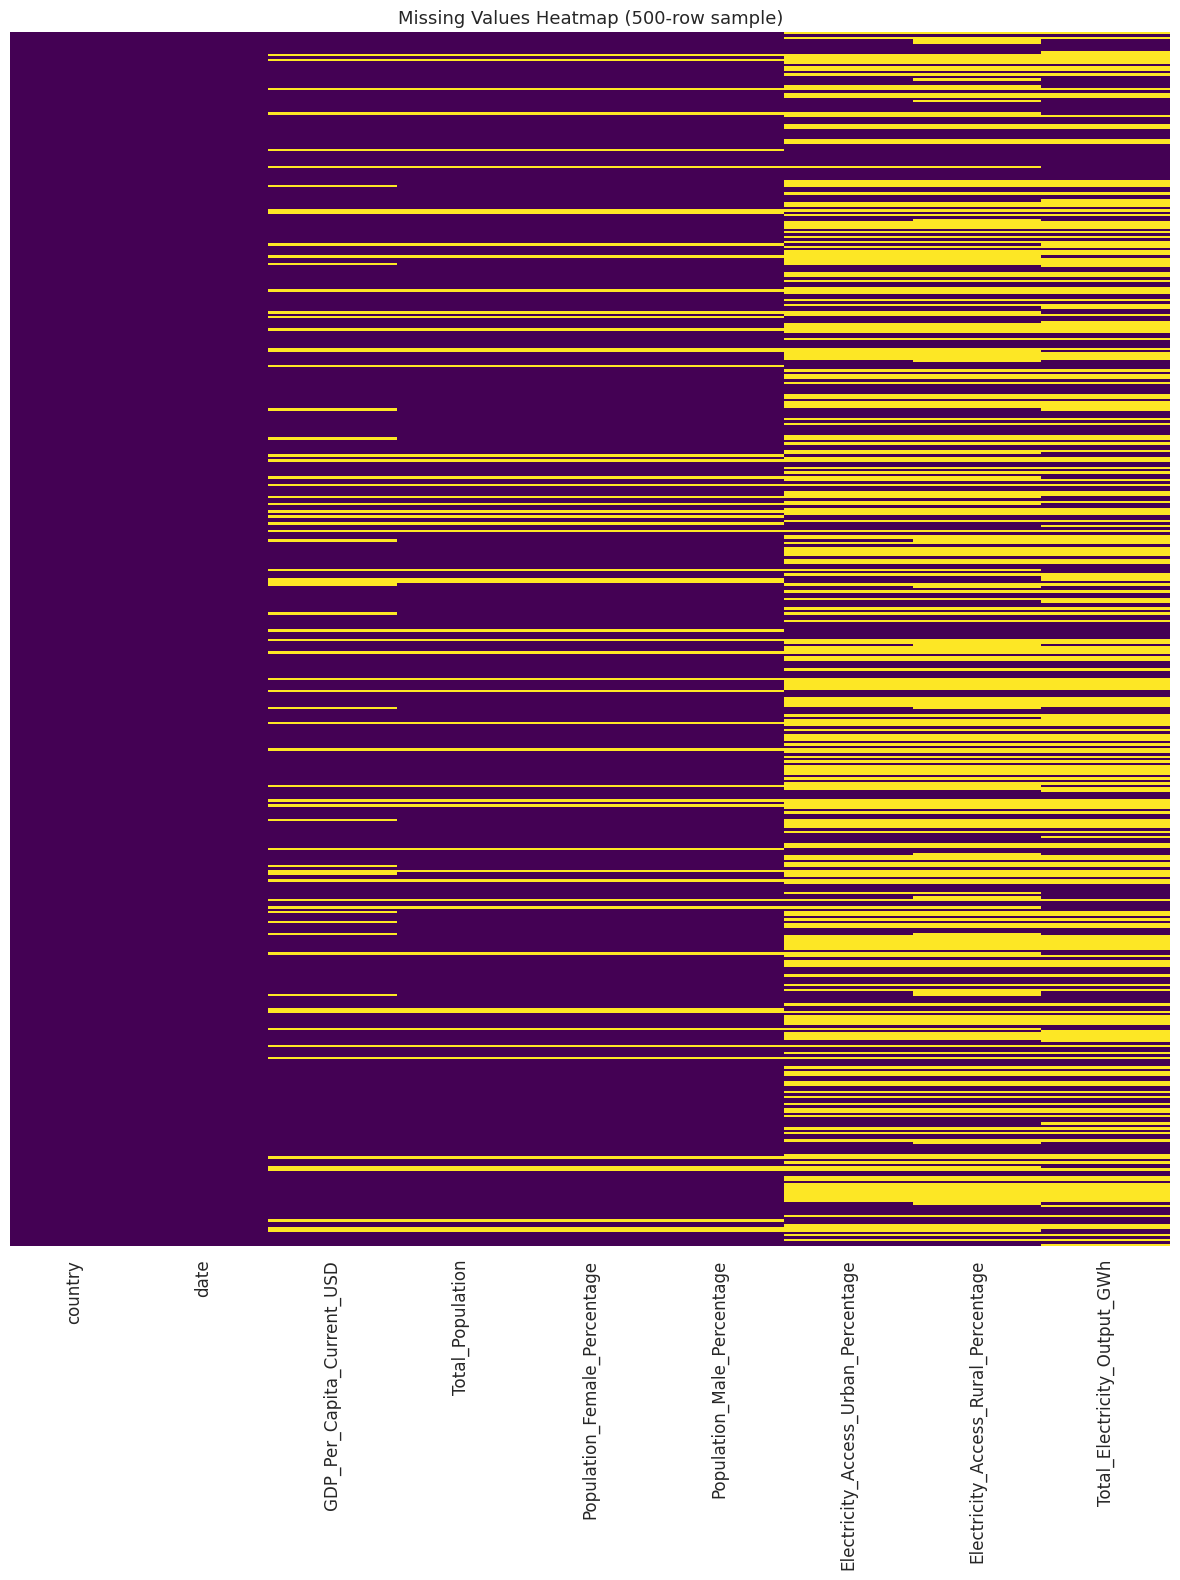


✅ Country-level rows: 5852 | Unique countries: 244
Year range: 2000 – 2024


In [4]:
# Missing values overview
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df)

# Heatmap of missing values (sample 500 rows for speed)
plt.figure(figsize=(12, 16))
sns.heatmap(df.sample(500, random_state=42).isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap (500-row sample)", fontsize=13)
plt.tight_layout()
plt.show()

# Aggregate/regional entries to drop for country-level analysis
REGIONAL_KEYWORDS = [
    "World", "income", "OECD", "Euro", "Asia", "Africa",
    "Latin", "Arab", "Europe", "Pacific", "dividend", "blend",
    "IDA", "IBRD", "fragile", "small states", "Caribbean",
    "Sub-Saharan", "South Asia", "Middle East", "North America",
    "East Asia", "Central Europe"
]
is_region = df["country"].str.contains("|".join(REGIONAL_KEYWORDS), case=False, na=False)
df_countries = df[~is_region].copy()
df_countries["date"] = df_countries["date"].astype(int)

print(f"\n✅ Country-level rows: {len(df_countries)} | Unique countries: {df_countries['country'].nunique()}")
print(f"Year range: {df_countries['date'].min()} – {df_countries['date'].max()}")

## 4. 🟢 Q1 — Countries with 100% Electricity Access by 2015

In [5]:
# Countries with BOTH urban and rural at 100% in at least one year <= 2015
full_access = df_countries[
    (df_countries["date"] <= 2015) &
    (df_countries["Electricity_Access_Urban_Percentage"] == 100) &
    (df_countries["Electricity_Access_Rural_Percentage"] == 100)
]["country"].unique()

print(f"✅ {len(full_access)} countries achieved 100% urban + rural electricity access by 2015:\n")
for i, c in enumerate(sorted(full_access), 1):
    print(f"  {i:3}. {c}")

# Bar chart
fig = px.bar(
    x=sorted(full_access),
    labels={"x": "Country", "y": ""},
    title=f"Countries with 100% Urban & Rural Electricity Access by 2015 ({len(full_access)} countries)",
    color=sorted(full_access),
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.update_layout(showlegend=False, xaxis_tickangle=-45, height=500)
fig.update_yaxes(visible=False)
fig.show(renderer='iframe_connected')

✅ 78 countries achieved 100% urban + rural electricity access by 2015:

    1. Albania
    2. Andorra
    3. Armenia
    4. Australia
    5. Austria
    6. Azerbaijan
    7. Bahrain
    8. Barbados
    9. Belarus
   10. Belgium
   11. Bosnia and Herzegovina
   12. Brunei Darussalam
   13. Bulgaria
   14. Canada
   15. Channel Islands
   16. China
   17. Croatia
   18. Cuba
   19. Curacao
   20. Cyprus
   21. Czech Republic
   22. Denmark
   23. Estonia
   24. Faeroe Islands
   25. Finland
   26. France
   27. French Polynesia
   28. Georgia
   29. Germany
   30. Greece
   31. Greenland
   32. Guam
   33. Hungary
   34. Iceland
   35. Ireland
   36. Isle of Man
   37. Israel
   38. Italy
   39. Japan
   40. Kazakhstan
   41. Korea, Rep.
   42. Kuwait
   43. Latvia
   44. Lebanon
   45. Liechtenstein
   46. Lithuania
   47. Luxembourg
   48. Macedonia, FYR
   49. Maldives
   50. Malta
   51. Moldova
   52. Netherlands
   53. New Caledonia
   54. New Zealand
   55. Northern Mariana Island

## 5. 🟢 Q2 — Global Average Rural Electricity Access Trend (2000–2016)

In [6]:
rural_trend = (
    df_countries[
        (df_countries["date"].between(2000, 2016)) &
        (df_countries["Electricity_Access_Rural_Percentage"].notna())
    ]
    .groupby("date")["Electricity_Access_Rural_Percentage"]
    .mean()
    .reset_index()
)

fig = px.line(
    rural_trend, x="date", y="Electricity_Access_Rural_Percentage",
    markers=True,
    title="🌾 Global Average Rural Electricity Access (2000–2016)",
    labels={"date": "Year", "Electricity_Access_Rural_Percentage": "Avg Rural Access (%)"},
    color_discrete_sequence=["#2ecc71"]
)
fig.update_layout(hovermode="x unified")
fig.add_annotation(
    x=2000, y=rural_trend.iloc[0]["Electricity_Access_Rural_Percentage"],
    text=f"Start: {rural_trend.iloc[0]['Electricity_Access_Rural_Percentage']:.1f}%",
    showarrow=True, arrowhead=2, bgcolor="lightyellow"
)
fig.add_annotation(
    x=2016, y=rural_trend.iloc[-1]["Electricity_Access_Rural_Percentage"],
    text=f"2016: {rural_trend.iloc[-1]['Electricity_Access_Rural_Percentage']:.1f}%",
    showarrow=True, arrowhead=2, bgcolor="lightgreen"
)
fig.show(renderer='iframe_connected')

print(f"\n📈 Rural access improved from "
      f"{rural_trend.iloc[0]['Electricity_Access_Rural_Percentage']:.1f}% (2000) to "
      f"{rural_trend.iloc[-1]['Electricity_Access_Rural_Percentage']:.1f}% (2016) — "
      f"+{rural_trend.iloc[-1]['Electricity_Access_Rural_Percentage'] - rural_trend.iloc[0]['Electricity_Access_Rural_Percentage']:.1f} pp")


📈 Rural access improved from 68.6% (2000) to 78.7% (2016) — +10.1 pp


## 6. 🟢 Q3 — Top 10 Countries by GDP Per Capita in 2023

In [7]:
top10_gdp = (
    df_countries[df_countries["date"] == 2023]
    .dropna(subset=["GDP_Per_Capita_Current_USD"])
    .nlargest(10, "GDP_Per_Capita_Current_USD")
    [["country", "GDP_Per_Capita_Current_USD", "Total_Population"]]
    .reset_index(drop=True)
)
top10_gdp.index += 1
display(top10_gdp.style.format({"GDP_Per_Capita_Current_USD": "${:,.0f}", "Total_Population": "{:,.0f}"}))

fig = px.bar(
    top10_gdp.sort_values("GDP_Per_Capita_Current_USD"),
    x="GDP_Per_Capita_Current_USD", y="country",
    orientation="h", text="GDP_Per_Capita_Current_USD",
    title="💰 Top 10 Countries by GDP Per Capita (2023)",
    labels={"GDP_Per_Capita_Current_USD": "GDP Per Capita (USD)", "country": ""},
    color="GDP_Per_Capita_Current_USD",
    color_continuous_scale="Blues"
)
fig.update_traces(texttemplate="$%{text:,.0f}", textposition="outside")
fig.update_layout(coloraxis_showscale=False, height=450)
fig.show(renderer='iframe_connected')

,country,GDP_Per_Capita_Current_USD,Total_Population
1,Monaco,"$256,800","38,956"
2,Liechtenstein,"$206,781","39,846"
3,Luxembourg,"$133,231","666,430"
4,Bermuda,"$132,604","64,698"
5,Ireland,"$106,819","5,311,538"
6,Switzerland,"$100,624","8,888,822"
7,Cayman Islands,"$99,144","73,038"
8,Norway,"$87,497","5,519,601"
9,Singapore,"$85,412","5,917,648"
10,Iceland,"$82,139","385,663"


## 7. 🟢 Q4 — Global Population Growth (2000–2024)

In [8]:
pop_trend = (
    df_countries[df_countries["Total_Population"].notna()]
    .groupby("date")["Total_Population"]
    .sum()
    .reset_index()
)

fig = px.area(
    pop_trend, x="date", y="Total_Population",
    title="🌎 Global Population Growth (2000–2024)",
    labels={"date": "Year", "Total_Population": "Total Population"},
    color_discrete_sequence=["#3498db"]
)
fig.update_traces(fill="tozeroy")
fig.update_yaxes(tickformat=".2s")

# Annotate milestones
for yr, label in [(2000, "6.1B"), (2010, "~6.9B"), (2022, "8B milestone"), (2024, "8.1B+")]:
    val = pop_trend[pop_trend["date"] == yr]["Total_Population"].values
    if len(val):
        fig.add_annotation(x=yr, y=val[0], text=label, showarrow=True, arrowhead=2,
                           bgcolor="white", bordercolor="gray")

fig.show(renderer='iframe_connected')

## 8. 🟡 Q5 — GDP Per Capita vs Electricity Access Correlation

The Pearson correlation is defined as:
$$r = \frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum(x_i-\bar{x})^2 \cdot \sum(y_i-\bar{y})^2}}$$

Urban  — Pearson r: 0.598 | Spearman ρ: 0.804
Rural  — Pearson r: 0.719 | Spearman ρ: 0.810


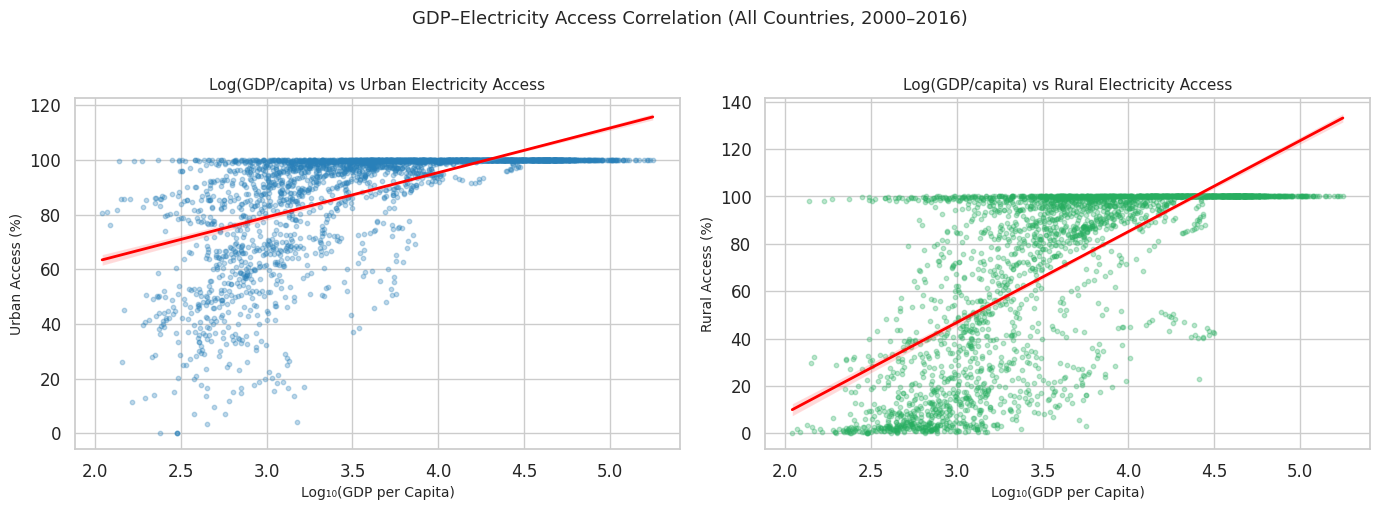

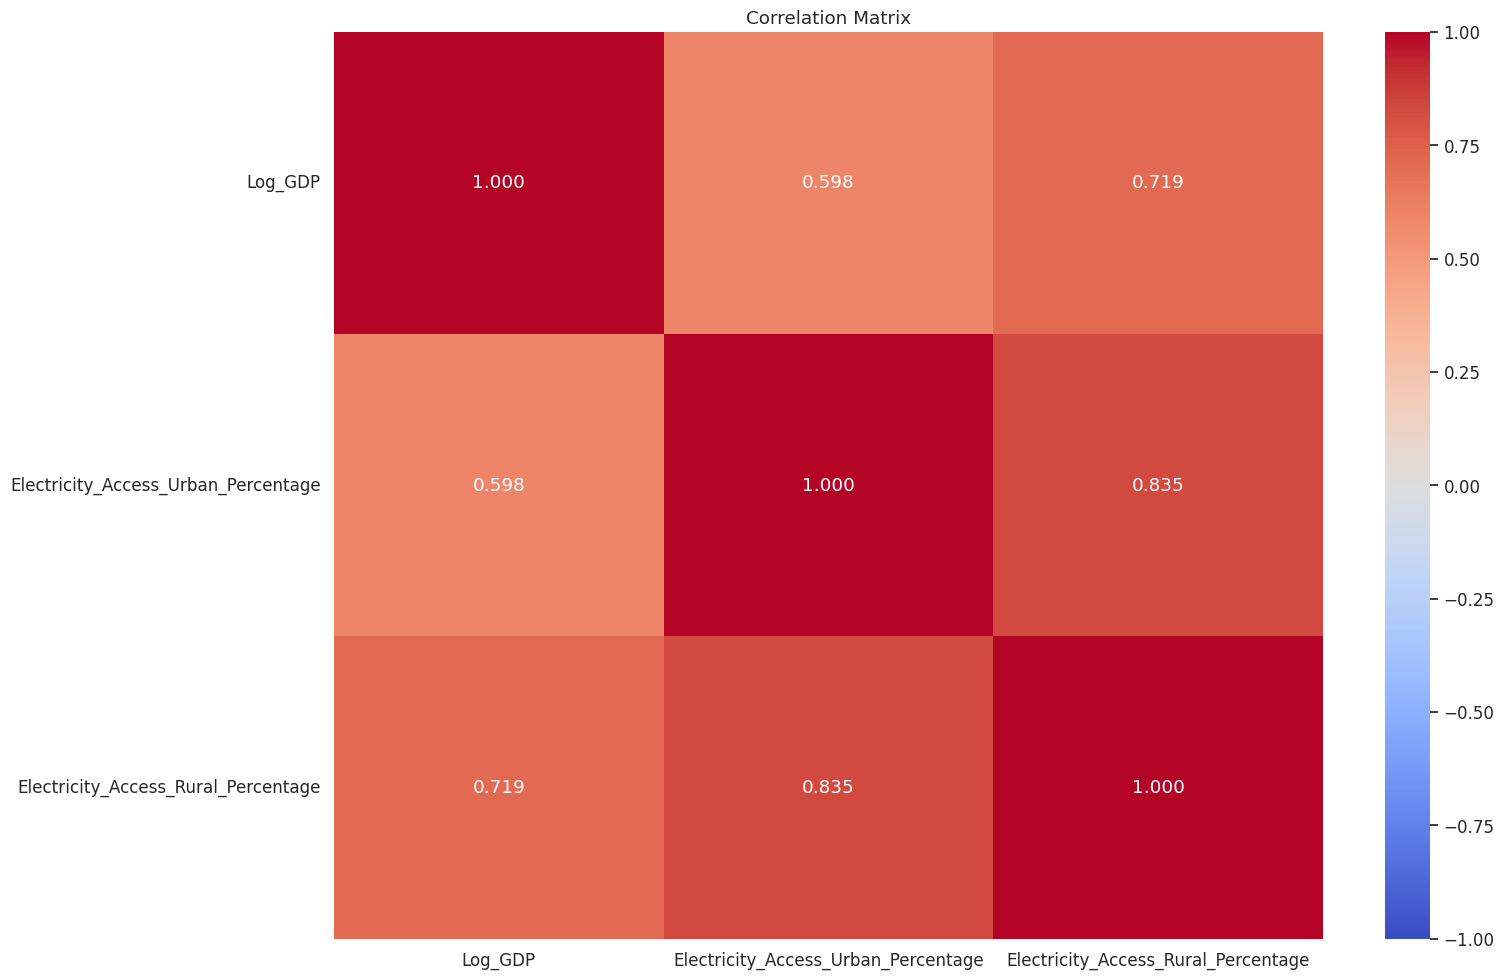

In [9]:
corr_df = df_countries[
    ["GDP_Per_Capita_Current_USD",
     "Electricity_Access_Urban_Percentage",
     "Electricity_Access_Rural_Percentage"]
].dropna()

# Log GDP
corr_df = corr_df.copy()
corr_df["Log_GDP"] = np.log10(corr_df["GDP_Per_Capita_Current_USD"])

# Pearson and Spearman correlations
for col in ["Electricity_Access_Urban_Percentage", "Electricity_Access_Rural_Percentage"]:
    pr, _ = stats.pearsonr(corr_df["Log_GDP"], corr_df[col])
    sr, _ = stats.spearmanr(corr_df["Log_GDP"], corr_df[col])
    print(f"{'Urban' if 'Urban' in col else 'Rural':6s} — Pearson r: {pr:.3f} | Spearman ρ: {sr:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, color, label in zip(
    axes,
    ["Electricity_Access_Urban_Percentage", "Electricity_Access_Rural_Percentage"],
    ["#2980b9", "#27ae60"],
    ["Urban", "Rural"]
):
    sns.regplot(data=corr_df, x="Log_GDP", y=col, ax=ax,
                scatter_kws={"alpha": 0.3, "s": 10, "color": color},
                line_kws={"color": "red", "lw": 2})
    ax.set_title(f"Log(GDP/capita) vs {label} Electricity Access", fontsize=11)
    ax.set_xlabel("Log₁₀(GDP per Capita)", fontsize=10)
    ax.set_ylabel(f"{label} Access (%)", fontsize=10)

plt.suptitle("GDP–Electricity Access Correlation (All Countries, 2000–2016)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_df[["Log_GDP",
                      "Electricity_Access_Urban_Percentage",
                      "Electricity_Access_Rural_Percentage"]].corr(),
            annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 9. 🟡 Q6 — Fastest Growing Regions in Rural Electricity Access

In [10]:
rural_pivot = df_countries[
    df_countries["Electricity_Access_Rural_Percentage"].notna() &
    df_countries["date"].isin([2000, 2016])
].pivot_table(index="country", columns="date", values="Electricity_Access_Rural_Percentage")

rural_pivot = rural_pivot.dropna()
rural_pivot.columns = ["Access_2000", "Access_2016"]
rural_pivot["Growth_pp"] = rural_pivot["Access_2016"] - rural_pivot["Access_2000"]
rural_pivot["Start_Level"] = pd.cut(
    rural_pivot["Access_2000"],
    bins=[0, 25, 50, 75, 101],
    labels=["<25%", "25-50%", "50-75%", ">75%"]
).astype(str)  # convert Categorical → str so Plotly color map works

top15 = rural_pivot.nlargest(15, "Growth_pp").reset_index()

fig = px.bar(
    top15.sort_values("Growth_pp"),
    x="Growth_pp", y="country", orientation="h",
    color="Start_Level",
    text="Growth_pp",
    title="🚀 Top 15 Fastest Rural Electricity Access Growth (2000–2016, pp change)",
    labels={"Growth_pp": "Growth (percentage points)", "country": "", "Start_Level": "2000 Access Level"},
    color_discrete_map={"<25%": "#e74c3c", "25-50%": "#e67e22", "50-75%": "#f1c40f", ">75%": "#2ecc71"},
    category_orders={"Start_Level": ["<25%", "25-50%", "50-75%", ">75%"]}
)
fig.update_traces(texttemplate="+%{text:.1f} pp", textposition="outside")
fig.update_layout(height=500)
fig.show(renderer='iframe_connected')


## 10. 🟡 Q7 — Electricity Output vs Population Size

$$E_{per\_capita} = \frac{\text{Total Electricity Output (GWh)} \times 10^6}{\text{Total Population}}$$

In [11]:
scatter_df = df_countries[
    df_countries["date"] == 2015
].dropna(subset=["Total_Population", "Total_Electricity_Output_GWh", "GDP_Per_Capita_Current_USD"]).copy()

scatter_df["Elec_Per_Capita_kWh"] = (
    scatter_df["Total_Electricity_Output_GWh"] * 1e6 / scatter_df["Total_Population"]
)

fig = px.scatter(
    scatter_df,
    x="Total_Population",
    y="Total_Electricity_Output_GWh",
    size="Elec_Per_Capita_kWh",
    color="GDP_Per_Capita_Current_USD",
    hover_name="country",
    log_x=True, log_y=True,
    title="⚡ Electricity Output vs Population (2015) — colored by GDP/capita",
    labels={
        "Total_Population": "Total Population (log scale)",
        "Total_Electricity_Output_GWh": "Total Electricity Output GWh (log scale)",
        "GDP_Per_Capita_Current_USD": "GDP/capita (USD)",
        "Elec_Per_Capita_kWh": "Per-capita kWh"
    },
    color_continuous_scale="Plasma",
    size_max=40
)
fig.update_layout(height=550)
fig.show(renderer='iframe_connected')

## 11. 🟡 Q8 — Urban–Rural Electricity Access Gap by Country

In [12]:
gap_df = df_countries.dropna(
    subset=["Electricity_Access_Urban_Percentage", "Electricity_Access_Rural_Percentage"]
).copy()
gap_df["Gap"] = gap_df["Electricity_Access_Urban_Percentage"] - gap_df["Electricity_Access_Rural_Percentage"]

avg_gap = gap_df.groupby("country")["Gap"].mean().sort_values(ascending=False).head(20).reset_index()
avg_gap.columns = ["country", "Avg_Gap_pp"]

fig = px.bar(
    avg_gap.sort_values("Avg_Gap_pp"),
    x="Avg_Gap_pp", y="country", orientation="h",
    title="🏙️ Top 20 Countries with Largest Urban–Rural Electricity Access Gap (2000–2016 avg)",
    labels={"Avg_Gap_pp": "Average Gap (Urban − Rural, pp)", "country": ""},
    color="Avg_Gap_pp", color_continuous_scale="Reds"
)
fig.update_layout(coloraxis_showscale=False, height=520)
fig.show()

# Trend for top 3 gap countries
top3 = avg_gap.nlargest(3, "Avg_Gap_pp")["country"].tolist()
gap_trend = gap_df[gap_df["country"].isin(top3)]

fig2 = px.line(
    gap_trend, x="date", y="Gap", color="country",
    markers=True,
    title=f"Gap Trend Over Time — Top 3 Countries: {', '.join(top3)}",
    labels={"Gap": "Urban−Rural Gap (pp)", "date": "Year"}
)
fig2.show(renderer='iframe_connected')

## 12. 🔴 Q9 — Forecasting Electricity Access Rates to 2030

Using the linear trend model:
$$\hat{y} = \beta_0 + \beta_1 t + \epsilon$$

In [13]:
# Select countries with sufficient data (at least 10 years of rural access)
forecast_countries = ["India", "Bangladesh", "Nigeria", "Kenya", "Ethiopia"]

fig = go.Figure()
future_years = np.arange(2000, 2031)

for country in forecast_countries:
    cdata = df_countries[
        (df_countries["country"] == country) &
        df_countries["Electricity_Access_Rural_Percentage"].notna()
    ].sort_values("date")

    if len(cdata) < 5:
        continue

    X = cdata["date"].values.reshape(-1, 1)
    y = cdata["Electricity_Access_Rural_Percentage"].values
    model = LinearRegression().fit(X, y)
    r2 = r2_score(y, model.predict(X))

    X_future = future_years.reshape(-1, 1)
    y_pred = np.clip(model.predict(X_future), 0, 100)

    # Confidence band (simple ±std of residuals)
    residuals_std = np.std(y - model.predict(X))

    fig.add_trace(go.Scatter(x=cdata["date"], y=y, mode="markers+lines",
                             name=f"{country} (actual)", opacity=0.8))
    fig.add_trace(go.Scatter(x=future_years, y=y_pred, mode="lines",
                             name=f"{country} forecast (R²={r2:.2f})",
                             line={"dash": "dash"}))
    fig.add_trace(go.Scatter(
        x=np.concatenate([future_years, future_years[::-1]]),
        y=np.concatenate([y_pred + residuals_std, (y_pred - residuals_std)[::-1]]),
        fill="toself", opacity=0.15, showlegend=False,
        line={"width": 0}
    ))

fig.add_hline(y=100, line_dash="dot", line_color="red",
              annotation_text="SDG-7 Target: 100%", annotation_position="top left")
fig.add_vline(x=2030, line_dash="dash", line_color="gray",
              annotation_text="2030 Deadline", annotation_position="top right")
fig.update_layout(
    title="🔮 Rural Electricity Access Forecast to 2030 (Linear Regression)",
    xaxis_title="Year", yaxis_title="Rural Electricity Access (%)",
    height=550, hovermode="x unified"
)
fig.show(renderer='iframe_connected')

## 13. 🔴 Q10 — Country Clustering by Electrification & Economic Profile

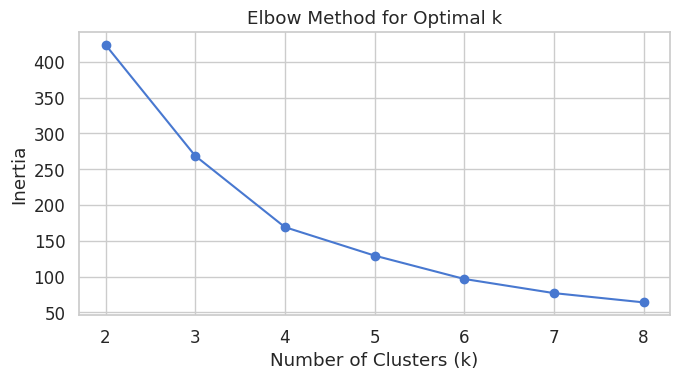


Cluster sizes:
Cluster_Label
Low Access / Low Income          115
Mid-Income Transitioning          35
High-Income Fully Electrified     26
Emerging Economies (Partial)       2
Name: count, dtype: int64


In [14]:
# Use 2015 snapshot
cluster_features = [
    "GDP_Per_Capita_Current_USD",
    "Electricity_Access_Urban_Percentage",
    "Electricity_Access_Rural_Percentage",
    "Total_Electricity_Output_GWh"
]

cluster_df = df_countries[df_countries["date"] == 2015][["country"] + cluster_features].dropna().copy()

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[cluster_features])

# Elbow method
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(K_range), inertias, "bo-")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

# Fit with k=4
km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["Cluster"] = km_final.fit_predict(X_scaled)

cluster_labels = {
    0: "High-Income Fully Electrified",
    1: "Emerging Economies (Partial)",
    2: "Low Access / Low Income",
    3: "Mid-Income Transitioning"
}
# Assign labels based on mean GDP within each cluster
cluster_means = cluster_df.groupby("Cluster")["GDP_Per_Capita_Current_USD"].mean().sort_values(ascending=False)
label_map = {orig: list(cluster_labels.values())[i] for i, orig in enumerate(cluster_means.index)}
cluster_df["Cluster_Label"] = cluster_df["Cluster"].map(label_map)

# PCA 2D projection
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)
cluster_df["PC1"] = pcs[:, 0]
cluster_df["PC2"] = pcs[:, 1]

fig = px.scatter(
    cluster_df, x="PC1", y="PC2",
    color="Cluster_Label", hover_name="country",
    title=f"🗺️ Country Clusters (K-Means, k=4) — PCA 2D Projection (2015)",
    labels={"PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)",
            "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)"},
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_traces(marker={"size": 8, "opacity": 0.85})
fig.update_layout(height=520, legend_title="Cluster")
fig.show(renderer='iframe_connected')

print("\nCluster sizes:")
print(cluster_df["Cluster_Label"].value_counts())

## 14. 🔴 Q11 — Identifying SDG-7 Off-Track Countries

For each country, the required annual growth rate to reach 100% access by 2030:
$$r_{required} = \frac{100 - \text{Access}_{2016}}{2030 - 2016} = \frac{100 - \text{Access}_{2016}}{14}$$

In [15]:
# Use rural access as the gap indicator (urban usually close to 100% already)
sdg_df = rural_pivot.copy().reset_index()
sdg_df.columns = ["country", "Access_2000", "Access_2016", "Growth_pp", "Start_Level"]

sdg_df["Historical_Rate_pp_per_yr"] = sdg_df["Growth_pp"] / 16   # 2000→2016
sdg_df["Required_Rate_pp_per_yr"] = (100 - sdg_df["Access_2016"]) / 14  # 2016→2030

sdg_df["Status"] = np.where(
    sdg_df["Access_2016"] >= 100, "✅ Already at 100%",
    np.where(
        sdg_df["Historical_Rate_pp_per_yr"] >= sdg_df["Required_Rate_pp_per_yr"],
        "🟡 On Track",
        "🔴 Off Track"
    )
)

off_track = sdg_df[sdg_df["Status"] == "🔴 Off Track"].sort_values("Access_2016")
on_track  = sdg_df[sdg_df["Status"] == "🟡 On Track"]
complete  = sdg_df[sdg_df["Status"] == "✅ Already at 100%"]

print(f"Total countries analyzed: {len(sdg_df)}")
print(f"  ✅ Already at 100%: {len(complete)}")
print(f"  🟡 On Track for 2030: {len(on_track)}")
print(f"  🔴 Off Track: {len(off_track)}")

# Top 20 most off-track
worst = off_track.nsmallest(20, "Access_2016")[["country", "Access_2016", "Historical_Rate_pp_per_yr", "Required_Rate_pp_per_yr"]]
worst.columns = ["Country", "Rural Access 2016 (%)", "Historical Rate (pp/yr)", "Required Rate (pp/yr)"]
worst = worst.reset_index(drop=True)
worst.index += 1
display(worst.style.format({
    "Rural Access 2016 (%)": "{:.1f}",
    "Historical Rate (pp/yr)": "{:.2f}",
    "Required Rate (pp/yr)": "{:.2f}"
}).background_gradient(subset=["Rural Access 2016 (%)"], cmap="RdYlGn"))

# Choropleth map
fig = px.choropleth(
    sdg_df,
    locations="country",
    locationmode="country names",
    color="Status",
    title="🗺️ SDG-7 Progress: Is Each Country On Track for Universal Electricity Access by 2030?",
    color_discrete_map={
        "✅ Already at 100%": "#2ecc71",
        "🟡 On Track": "#f1c40f",
        "🔴 Off Track": "#e74c3c"
    },
    hover_data=["Access_2016", "Required_Rate_pp_per_yr"]
)
fig.update_layout(height=520)
fig.show(renderer='iframe_connected')

Total countries analyzed: 183
  ✅ Already at 100%: 101
  🟡 On Track for 2030: 32
  🔴 Off Track: 50


,Country,Rural Access 2016 (%),Historical Rate (pp/yr),Required Rate (pp/yr)
1,Burkina Faso,0.8,-0.10,7.09
2,Liberia,1.3,0.08,7.05
3,Mali,1.8,0.04,7.02
4,Chad,2.2,0.11,6.98
5,Sierra Leone,2.5,-0.02,6.96
6,Zambia,2.7,0.03,6.95
7,Malawi,4.0,0.19,6.86
8,Niger,4.7,0.27,6.81
9,South Sudan,5.9,0.37,6.72
10,Papua New Guinea,15.5,0.69,6.04


---

## ✅ Key Findings Summary

| # | Question | Finding |
|---|----------|---------|
| Q1 | 100% access by 2015 | Mostly high-income countries (Europe, Caribbean, parts of Asia-Pacific) |
| Q2 | Rural access trend | Global average grew steadily 2000–2016; large gaps remain |
| Q3 | GDP leaders 2023 | Luxembourg, Norway, Switzerland, Bermuda, Iceland top the list |
| Q4 | Population growth | World grew from ~6.1B (2000) to ~8.1B+ (2024) |
| Q5 | GDP–Electricity correlation | Strong positive correlation (Pearson r > 0.7) — richer = more access |
| Q6 | Fastest rural growth | Several South Asian & East African countries improved >40 pp in 16 years |
| Q7 | Output vs population | Positive log-log relationship; high-GDP countries produce disproportionately more |
| Q8 | Urban–rural gap | Sub-Saharan Africa shows the largest persistent gaps |
| Q9 | Forecasting | Many developing countries will NOT reach 100% by 2030 at current pace |
| Q10 | Clustering | 4 distinct country groups: fully electrified / transitioning / low-income / emerging |
| Q11 | SDG-7 off-track | ~50–70 countries are off-track for universal rural electricity access by 2030 |

---
**Dataset Source:** [World Bank Open Data](https://data.worldbank.org/)  
**License:** CC BY 4.0